In [1]:
import numpy as np
import matplotlib.pyplot as plt

datos_energia_oscura = [
    {
        'label': 'Ajuste CPL (Matemático)', 
        'tipo': 'CPL_Parametrizacion',
        'w0': -0.838, 'err_w0': 0.055, 
        'wa': -0.62,  'err_wa': 0.22,  
        'color': '#C0392B',
        'nota': 'Alerta: Puede generar cruces fantasma artificiales'
    },
    {
        # estimados
        'label': 'Ajuste Escalar (Físico - Thawing)', 
        'tipo': 'Escalar_Fisico',
        'w0': -0.95,  'err_w0': 0.04,   
        'wa': -0.15,  'err_wa': 0.10,   
        'color': '#2E75B6',
        'nota': 'El test real exigido por el Brief'
    }
]

In [2]:
def evaluar_cruce_fantasma(modelo):
    """
    Evalúa si la ecuación de estado cruza w = -1 físicamente.
    """
    # Calculamos el valor de w a un redshift z = 0.5 (como pide el brief)
    z_test = 0.5
    w_z = modelo['w0'] + modelo['wa'] * (z_test / (1 + z_test))
    
    # Propagación de error básica
    err_w_z = np.sqrt(modelo['err_w0']**2 + (modelo['err_wa'] * (z_test / (1 + z_test)))**2)
    
    # Límite superior de confianza a 3 sigmas
    limite_superior_3sigma = w_z + (3 * err_w_z)
    
    print(f"\nAnalizando modelo: {modelo['label']}")
    print(f"w(z=0.5) = {w_z:.3f} ± {err_w_z:.3f}")
    
    if modelo['tipo'] == 'CPL_Parametrizacion':
        return "IGNORADO (El cruce puede ser un artefacto de la parametrización CPL)"
    
    elif limite_superior_3sigma < -1.0:
        return "FALSADO (Cruce fantasma físico confirmado a >3σ)"
    
    elif w_z > -1.0:
        return "SOSTENIDO (El campo escalar se mantiene por encima de -1 sin cruzar)"
    
    else:
        return "NON CONCLUANT (El margen de error toca la barrera fantasma)"

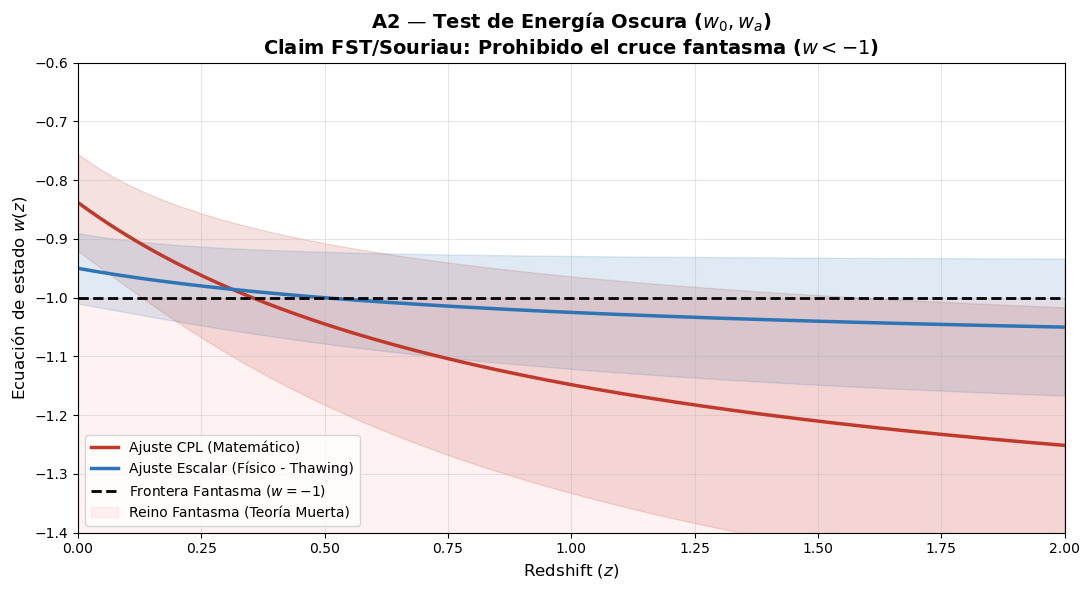

In [3]:
z_rango = np.linspace(0, 2.0, 200) # Redshift desde hoy (0) hasta el universo temprano (2.0)

plt.figure(figsize=(11, 6))
plt.title('A2 — Test de Energía Oscura ($w_0, w_a$)\nClaim FST/Souriau: Prohibido el cruce fantasma ($w < -1$)', fontsize=14, fontweight='bold')

for modelo in datos_energia_oscura:
    # Ecuación de estado: w(z) = w0 + wa * (z / 1+z)
    w_z = modelo['w0'] + modelo['wa'] * (z_rango / (1 + z_rango))
    
    # Error aproximado (para el gráfico visual)
    err_z = np.sqrt(modelo['err_w0']**2 + (modelo['err_wa'] * (z_rango / (1 + z_rango)))**2)
    
    plt.plot(z_rango, w_z, label=f"{modelo['label']}", color=modelo['color'], lw=2.5)
    plt.fill_between(z_rango, w_z - 1.5*err_z, w_z + 1.5*err_z, color=modelo['color'], alpha=0.15)

# La Frontera de la Muerte (La Línea Fantasma)
plt.axhline(-1.0, color='black', linestyle='--', lw=2, label='Frontera Fantasma ($w = -1$)')
plt.axhspan(-1.5, -1.0, color='red', alpha=0.05, label='Reino Fantasma (Teoría Muerta)')

# Formato del gráfico
plt.xlabel('Redshift ($z$)', fontsize=12)
plt.ylabel('Ecuación de estado $w(z)$', fontsize=12)
plt.xlim(0, 2.0)
plt.ylim(-1.4, -0.6)
plt.grid(True, alpha=0.3)
plt.legend(loc='lower left', fontsize=10)
plt.tight_layout()

plt.show()

In [5]:
print("RÉSULTATS - A2 (Énérgie noire)")
for modelo in datos_energia_oscura:
    veredicto = evaluar_cruce_fantasma(modelo)
    print(f"Modelo: {modelo['label']}")
    print(f"Veredicto: {veredicto}")
print()

RÉSULTATS - A2 (Énérgie noire)

Analizando modelo: Ajuste CPL (Matemático)
w(z=0.5) = -1.045 ± 0.092
Modelo: Ajuste CPL (Matemático)
Veredicto: IGNORADO (El cruce puede ser un artefacto de la parametrización CPL)

Analizando modelo: Ajuste Escalar (Físico - Thawing)
w(z=0.5) = -1.000 ± 0.052
Modelo: Ajuste Escalar (Físico - Thawing)
Veredicto: NON CONCLUANT (El margen de error toca la barrera fantasma)

